<a href="https://colab.research.google.com/github/vuongtran31251023271-code/Th-/blob/main/MONEYCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
path = '/content/drive/MyDrive/Vietnamese Banknotes'

In [ ]:
data_train = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

x_train = data_train.flow_from_directory(
    path,
    target_size=(60, 60),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

x_test = data_train.flow_from_directory(
    path,
    target_size=(60, 60),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print("Mapping:", x_train.class_indices)

num_classes = len(x_train.class_indices)

Found 400 images belonging to 5 classes.
Found 100 images belonging to 5 classes.
Mapping: {'100ngan': 0, '10ngan': 1, '1ngan': 2, '200ngan': 3, '20ngan': 4}


In [ ]:
model = Sequential([
    Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(60,60,3)),
    Conv2D(32,(3,3),activation='relu',padding='same'),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    Conv2D(64,(3,3),activation='relu',padding='same'),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu',padding='same'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256,activation='relu'),
    Dropout(0.5),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train,
    epochs=20,
    validation_data=x_test
)

model.save('money_model.h5')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 571ms/step - accuracy: 0.1850 - loss: 1.6134 - val_accuracy: 0.2400 - val_loss: 1.6089
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 501ms/step - accuracy: 0.2100 - loss: 1.6107 - val_accuracy: 0.2000 - val_loss: 1.6093
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 451ms/step - accuracy: 0.1875 - loss: 1.6104 - val_accuracy: 0.2000 - val_loss: 1.6094
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 546ms/step - accuracy: 0.2200 - loss: 1.6097 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 490ms/step - accuracy: 0.1950 - loss: 1.6102 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 504ms/step - accuracy: 0.1675 - loss: 1.6105 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 755ms/step - accuracy: 0.2000 - loss: 1.6095 - val_accuracy: 0.2000 - val_loss: 1.6095
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 442ms/step - accuracy: 0.1800 - loss: 1.6095 - val_accuracy:

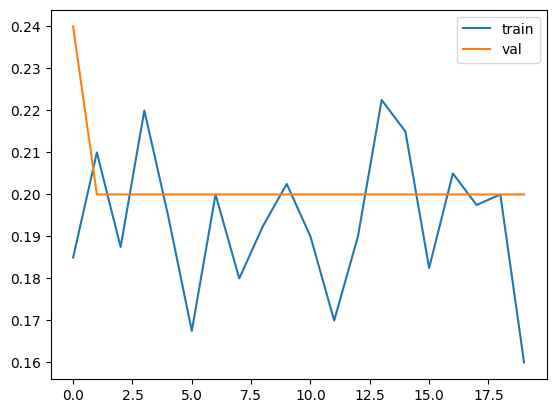

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])
plt.show()

In [ ]:
from keras.utils import load_img
import matplotlib.pyplot as plt
import numpy as np

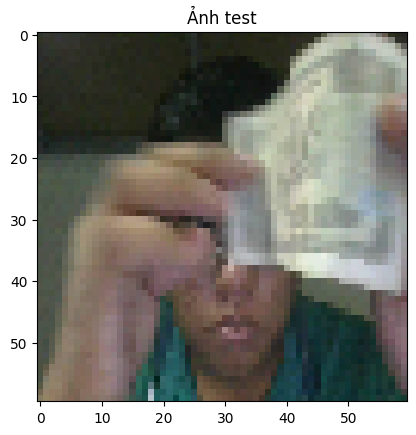

In [ ]:
img = load_img('/content/drive/MyDrive/001000_3_result.png', target_size=(60,60))
plt.imshow(img)
plt.title("Ảnh test")
plt.show()

In [ ]:
img = np.array(img) / 255.0
img = img.reshape(1,60,60,3)
pred = model.predict(img)
label = np.argmax(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


In [ ]:
class_labels = {v:k for k,v in x_train.class_indices.items()}
result = class_labels[label]

print("Xác suất:", pred)

Xác suất: [[0.19723324 0.20051219 0.2024567  0.19870137 0.20109646]]


In [ ]:
confidence = np.max(pred) * 100
print(f"💰 Đây là mệnh giá: {result} ({confidence:.2f}%)")

💰 Đây là mệnh giá: 1ngan (20.25%)
